In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns

In [2]:
df=pd.read_csv(r'D:\fsds\projects\Student Marks Predictor\Dataset\student_info.csv')

In [3]:
df.head()

,study_hours,student_marks
0,6.83,78.50
1,6.56,76.74
2,NaN,78.68
3,5.67,71.82
4,8.67,84.19


In [4]:
df.tail()

,study_hours,student_marks
195,7.53,81.67
196,8.56,84.68
197,8.94,86.75
198,6.60,78.05
199,8.35,83.50


In [5]:
df.shape

(200, 2)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   study_hours    195 non-null    float64
 1   student_marks  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [7]:
df.describe()

,study_hours,student_marks
count,195.000000,200.00000
mean,6.995949,77.93375
std,1.253060,4.92570
min,5.010000,68.57000
25%,5.775000,73.38500
50%,7.120000,77.71000
75%,8.085000,82.32000
max,8.990000,86.99000


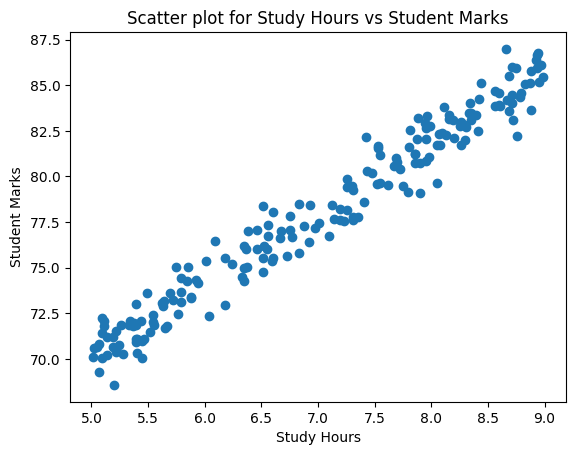

In [8]:
plt.scatter(x=df.study_hours, y=df.student_marks)
plt.xlabel('Study Hours')
plt.ylabel('Student Marks')
plt.title('Scatter plot for Study Hours vs Student Marks')
plt.show()

### Preparing data for applying the algorithm

In [9]:
df.isnull().sum()

study_hours      5
student_marks    0
dtype: int64

In [10]:
df.mean()

study_hours       6.995949
student_marks    77.933750
dtype: float64

In [11]:
df1=df.fillna(df.mean())

In [12]:
df1.isnull().sum()

study_hours      0
student_marks    0
dtype: int64

In [13]:
df1.head()

,study_hours,student_marks
0,6.830000,78.50
1,6.560000,76.74
2,6.995949,78.68
3,5.670000,71.82
4,8.670000,84.19


### Splitting th data into train and test data

In [14]:
X= df1.drop('student_marks', axis='columns')
y=df1.drop('study_hours', axis='columns')
print(f'Shape of X: {X.shape} and Shape of y: {y.shape}')

Shape of X: (200, 1) and Shape of y: (200, 1)


In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=51)
print(f'Shape of X_train: {X_train.shape}, X_test: {X_test.shape}, y_train: {y_train.shape}, y_test: {y_test.shape}')

Shape of X_train: (160, 1), X_test: (40, 1), y_train: (160, 1), y_test: (40, 1)


### Model Selection and model training

In [16]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()

In [17]:
lr.fit(X_train, y_train)

LinearRegression()

In [18]:
lr.coef_

array([[3.93571802]])

In [19]:
lr.intercept_

array([50.44735504])

In [20]:
m=3.93
c=50.44
y=m*4+c
print(f'Predicted marks for 4 hours of study: {y}')

Predicted marks for 4 hours of study: 66.16


In [21]:
lr.predict([[4]])[0][0].round(2)

c:\Users\bhara\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


66.19

In [22]:
y_pred=lr.predict(X_test)
y_pred

array([[83.11381458],
       [78.9025963 ],
       [84.57003024],
       [85.82946001],
       [84.72745896],
       [80.75238377],
       [72.84159055],
       [71.66087515],
       [73.23516235],
       [71.66087515],
       [73.47130543],
       [76.38373677],
       [73.23516235],
       [73.58937697],
       [82.95638585],
       [70.40144538],
       [73.23516235],
       [78.74516758],
       [75.55723598],
       [82.68088559],
       [76.65923703],
       [70.48015974],
       [74.77009238],
       [77.98143645],
       [85.59331693],
       [82.56281405],
       [76.42309395],
       [85.0423164 ],
       [78.39095296],
       [81.38209865],
       [81.73631327],
       [83.15317176],
       [82.20859943],
       [81.10659839],
       [73.58937697],
       [71.1492318 ],
       [71.89701823],
       [81.53952737],
       [72.60544747],
       [71.93637541]])

In [23]:
pd.DataFrame(np.c_[X_test, y_test, y_pred], columns=['Study Hours', 'Actual Marks', 'Predicted Marks'])

,Study Hours,Actual Marks,Predicted Marks
0,8.300000,82.02,83.113815
1,7.230000,77.55,78.902596
2,8.670000,84.19,84.570030
3,8.990000,85.46,85.829460
4,8.710000,84.03,84.727459
5,7.700000,80.81,80.752384
6,5.690000,73.61,72.841591
7,5.390000,70.90,71.660875
8,5.790000,73.14,73.235162
9,5.390000,73.02,71.660875


### Fine-tuning the model

In [24]:
lr.score(X_test, y_test)

0.9514124242154464

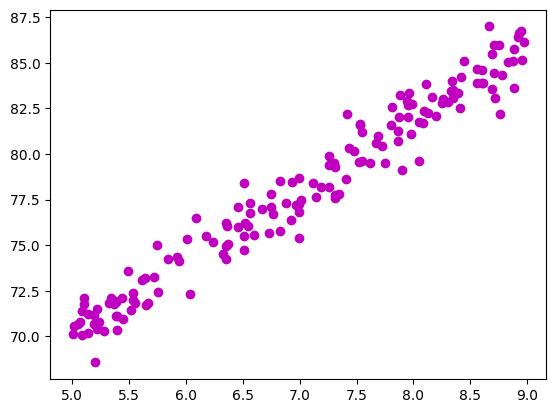

In [25]:
plt.scatter(X_train, y_train, color='m', label='Training Data')

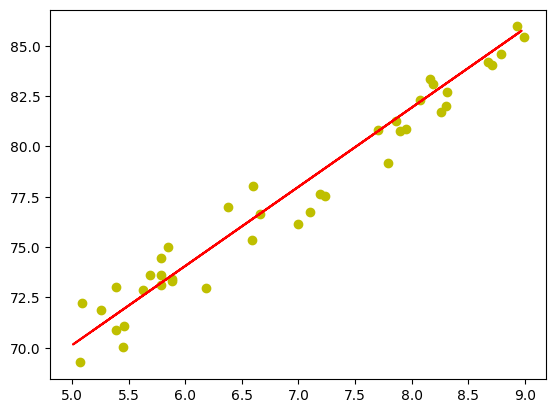

In [26]:
plt.scatter(X_test, y_test, color='y', label='Actual Marks')
plt.plot(X_train, lr.predict(X_train), color='r', label='Regression Line')

### Exporting the model

In [27]:
import joblib
joblib.dump(lr, 'student_marks_predictor_model.pkl')

['student_marks_predictor_model.pkl']

In [28]:
import os
os.getcwd()

'd:\\fsds\\projects\\Student Marks Predictor'

In [29]:
model= joblib.load('student_marks_predictor_model.pkl')

model.predict([[12.59]])[0][0].round(2)

c:\Users\bhara\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


100.0